# Predicción de Citas Médicas por Estado

### SARIMAX Es un modelo estadistico para pronosticar series de tiempo que representan tendencia y estacionalidad.

### Planteamiento del problema
El Instituto de Seguridad y Servicios Sociales de los Trabajadores del Estado (ISSSTE) administra miles de citas médicas cada mes en todo México. La demanda de atención varía de manera significativa entre las distintas delegaciones y a lo largo del año, influenciada por factores como estacionalidad, días festivos, campañas de salud y picos de enfermedades estacionales.

La falta de una herramienta de predicción confiable puede generar:

Sobrecarga en la agenda médica en ciertos periodos, afectando la calidad de la atención.

Subutilización de recursos en épocas de baja demanda.

Dificultades en la planeación de personal, infraestructura y suministros médicos.

Actualmente, la programación se realiza principalmente en función de la experiencia previa del personal y revisiones periódicas de datos históricos, lo que puede limitar la capacidad de respuesta ante variaciones abruptas en la demanda.

Este cuaderno busca desarrollar un modelo estadístico SARIMAX que permita:

Analizar el comportamiento histórico de las citas médicas.

Capturar patrones de tendencia y estacionalidad.

Generar predicciones a corto y mediano plazo del número de citas agendadas por delegación.

Proveer una base sólida para optimizar la asignación de recursos humanos y materiales en cada estado.

El objetivo final es mejorar la eficiencia operativa del ISSSTE y garantizar una atención médica más oportuna y equitativa para los derechohabientes.

In [4]:
# Importar las librerias 
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Cargar archivo CSV
df = pd.read_csv("ISSSTE_22_citas_medicas_agendadas.csv")

In [6]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

## Exploración Inicial 

<Figure size 1800x800 with 0 Axes>

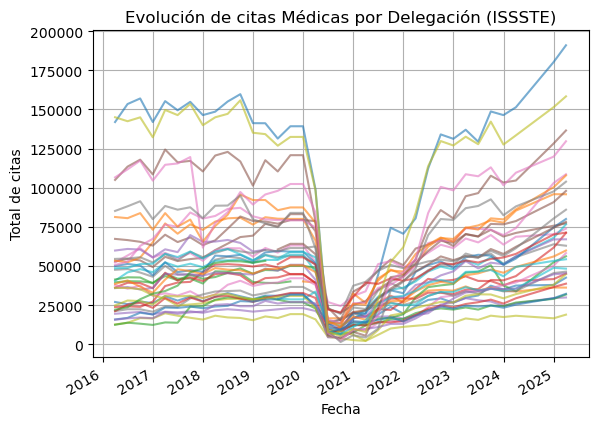

In [8]:
# Evolución de citas por delegación 
# Agrupar fecha y delegación 
evolucion_delegacion = df.groupby(["fecha","delegacion_issste"])["citas"].sum().unstack()

# Grafico 
plt.figure(figsize=(18,8))
evolucion_delegacion.plot(legend=False, alpha=0.6)
plt.title("Evolución de citas Médicas por Delegación (ISSSTE)")
plt.xlabel("Fecha")
plt.ylabel("Total de citas")
plt.grid(True)
plt.show()

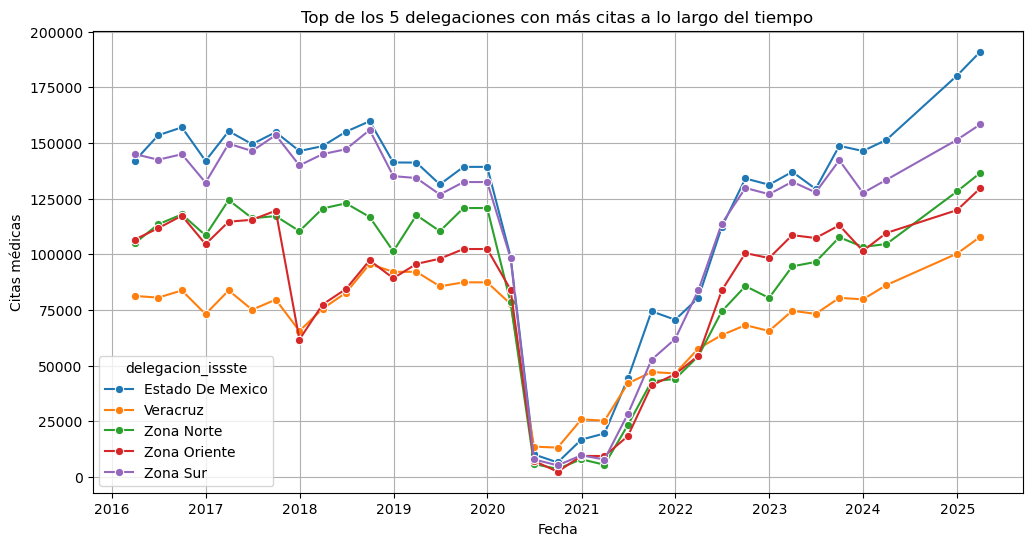

In [9]:
top_estados = df.groupby("delegacion_issste")["citas"].sum().sort_values(ascending=False).head(5).index

df_top  = df[df["delegacion_issste"].isin(top_estados)]

#Agrupar por fecha y estado
serie_top = df_top.groupby(["fecha","delegacion_issste"])["citas"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=serie_top, x="fecha", y="citas", hue="delegacion_issste", marker="o")
plt.title("Top de los 5 delegaciones con más citas a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Citas médicas")
plt.grid(True)
plt.show()

## Total de citas por año 

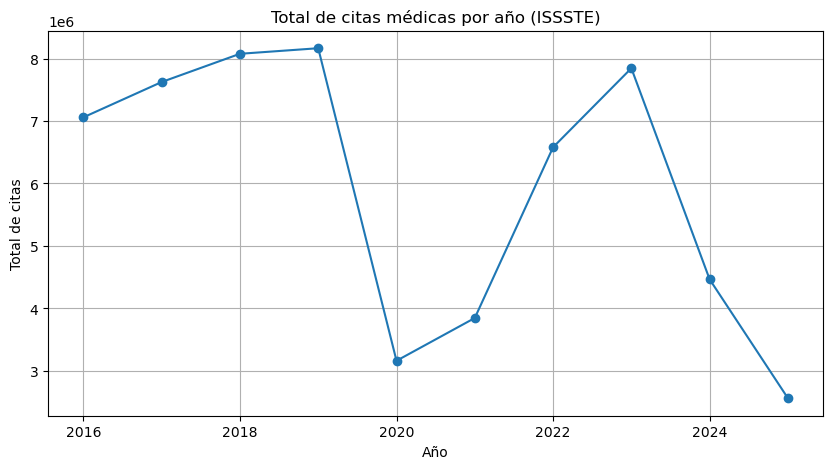

In [11]:
citas_por_anio= df.groupby("anio")["citas"].sum()

#Grafico
plt.figure(figsize=(10,5))
plt.plot(citas_por_anio.index, citas_por_anio.values, marker="o", linestyle="-")
plt.title("Total de citas médicas por año (ISSSTE)")
plt.xlabel("Año")
plt.ylabel("Total de citas")
plt.grid(True)
plt.show()

## Revisar si la serie es estacionaria 

Prueba Dickey-Fuller:
Estadistico ADF:-1.6157
La serie no es estacionaria
Metricas del modelo
MAE: 2831.16 citas
rmse: 3217.23 citas
r2: 0.78 citas


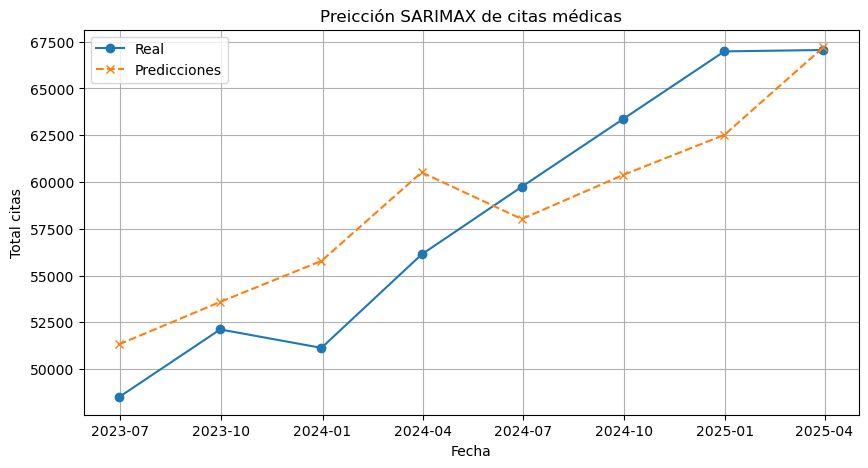

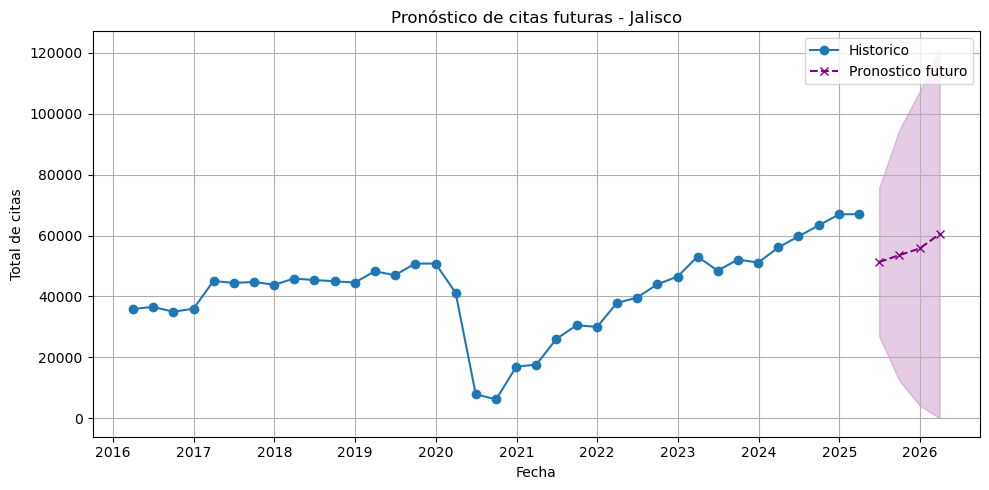

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def sarimax_model(estado):
    datos = df[df["delegacion_issste"]==estado]
    #Agrupar por fecha y sumer el total de citas por trimestre
    serie = datos.groupby("fecha")["citas"].sum().sort_index()
    # Establecer la frecuencia trimestral para serie temporal
    serie = serie.asfreq("Q")
    # Rellenar valores faltantes
    serie = serie.interpolate(method="linear")
    # Prueba de Dickey-Fuller
    resultado_adf = adfuller(serie.dropna())
    print("Prueba Dickey-Fuller:")
    print(f"Estadistico ADF:{resultado_adf[0]:.4F}")
    if resultado_adf[1] < 0.05:
        print("La serie es estacioria")
    else:
        print("La serie no es estacionaria")
    # Convertir a Dataframe la serie
    serie_df = serie.to_frame(name="citas")
    #Separar los datos 80/20
    train_df, test_df = train_test_split(serie_df, test_size=0.2, shuffle=False)
    # P= 1 Componente autorregresivo
    # d=1 Diferenciación para ser estacionaria la serie (elimina tendencia)
    # q=1 Comnponente de media movil

    # seasonal_order
    # P = 1 Componente AR estacional: considera la cita del mismo trimestre anterior
    # D = 1 Diferenciación estacional
    # Q = 1 MA Estacional: corrige errores estacionales.
    # S = 4 Periodicidad estacional: 4 trimestres por año
    modelo = SARIMAX(train_df["citas"], order=(1,1,1), seasonal_order=(1,1,1,4))
    modelo_entrenado = modelo.fit(disp=False)
    #Hacer prediccion
    pred = modelo_entrenado.predict(start=test_df.index[0], end=test_df.index[-1])

    #Calcular metricas 
    mae = mean_absolute_error(test_df["citas"], pred)
    rmse = np.sqrt(mean_squared_error(test_df["citas"], pred))
    r2 = r2_score(test_df["citas"], pred)

    #Mostrar los resultados
    print("Metricas del modelo")
    print("MAE:", round(mae,2), "citas")
    print("rmse:", round(rmse,2), "citas")
    print("r2:", round(r2,2), "citas")
    
    #Grafica de valores reales vs predichos
    plt.figure(figsize=(10,5))
    plt.plot(test_df.index, test_df["citas"], label="Real", marker="o")
    plt.plot(test_df.index, pred, label="Predicciones", marker="x", linestyle="--")
    plt.title("Preicción SARIMAX de citas médicas")
    plt.xlabel("Fecha")
    plt.ylabel("Total citas")
    plt.legend()
    plt.grid(True)
    plt.show()
    # Proyeccion de futuros trimestres
    pasos_futuros = 4
    forecast = modelo_entrenado.get_forecast(steps= pasos_futuros)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()
    # Crear un indexe futuro
    ultimo_trimestre = serie_df.index[-1]
    fechas_futuras = pd.date_range(start=ultimo_trimestre + pd.offsets.QuarterEnd(), 
                                   periods= pasos_futuros,freq="Q" 
                                  )
    #Graficar la predicion futura
    plt.figure(figsize=(10, 5))
    plt.plot(serie_df.index, serie_df['citas'], label='Historico', marker='o')
    plt.plot(fechas_futuras, forecast_mean, label='Pronostico futuro', marker='x', linestyle='--', color='purple')
    plt.fill_between(fechas_futuras, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='purple', alpha=0.2)
    plt.title(f"Pronóstico de citas futuras - {estado}")
    plt.xlabel("Fecha")
    plt.ylabel("Total de citas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

sarimax_model("Jalisco")
    

### 🟣 Línea punteada morada (Pronóstico futuro):
Representa la predicción de citas para los próximos 4 trimestres (2025-Q4 a 2026-Q3).

Se obtuvo utilizando el modelo SARIMAX, que considera tanto patrones pasados como estacionalidad (cada 4 trimestres).

### 🟪 Área sombreada morada (Intervalo de confianza):
Esta franja muestra el rango de valores posibles donde el modelo espera que estén las citas reales en el futuro.

Mientras más ancha, más incertidumbre tiene el modelo.

Por ejemplo, el modelo predice para 2026-Q1 un promedio de ~57,000 citas, pero podrían oscilar entre ~30,000 y ~120,000.

### 1. 📆 Planeación operativa del ISSSTE
Prever cuántas citas se agendarán por trimestre permite asignar personal médico, insumos y recursos de forma más eficiente.

Anticipar temporadas altas o bajas para evitar saturación o subutilización.

### 2. 👩‍⚕️ Optimización de agendas médicas
Permite anticipar la carga de trabajo en ciertas especialidades o delegaciones.

Ayuda a ajustar horarios, turnos y días de atención.

### Link:
https://datos.gob.mx/dataset/citas_medicas_agendadas_derechohabientes